In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier


In [149]:
# load iris dataset

data = pd.read_csv("Iris.csv")
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [150]:
# delete the column 'Id' 

df = data.drop(columns = ['Id'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [151]:
# check any missing values

df.isna()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [152]:
# display a stats about this data

df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [153]:
# information about this data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [154]:
# display no. of samples on each class
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

# preprocessing the dataset


In [155]:
# check any missing values

df.isna()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [156]:
# check for null values

df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

# Exploratry Data Analysis

array([[<Axes: title={'center': 'SepalLengthCm'}>,
        <Axes: title={'center': 'SepalWidthCm'}>],
       [<Axes: title={'center': 'PetalLengthCm'}>,
        <Axes: title={'center': 'PetalWidthCm'}>]], dtype=object)

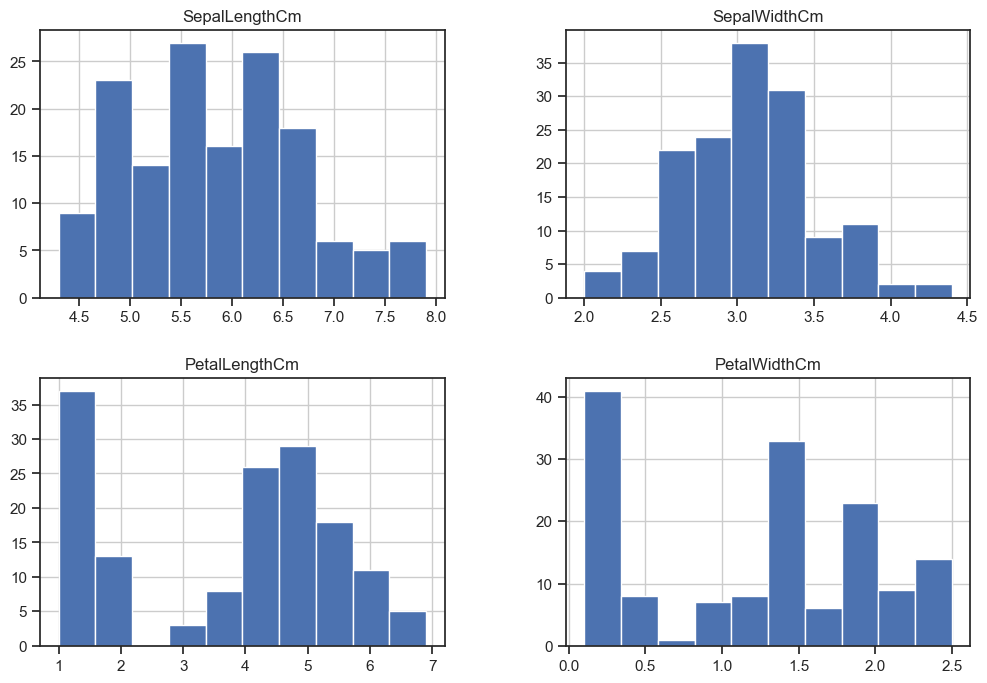

In [157]:
# Histogram Plot

df.hist(bins=None, figsize=(12,8))

# use seaborn 

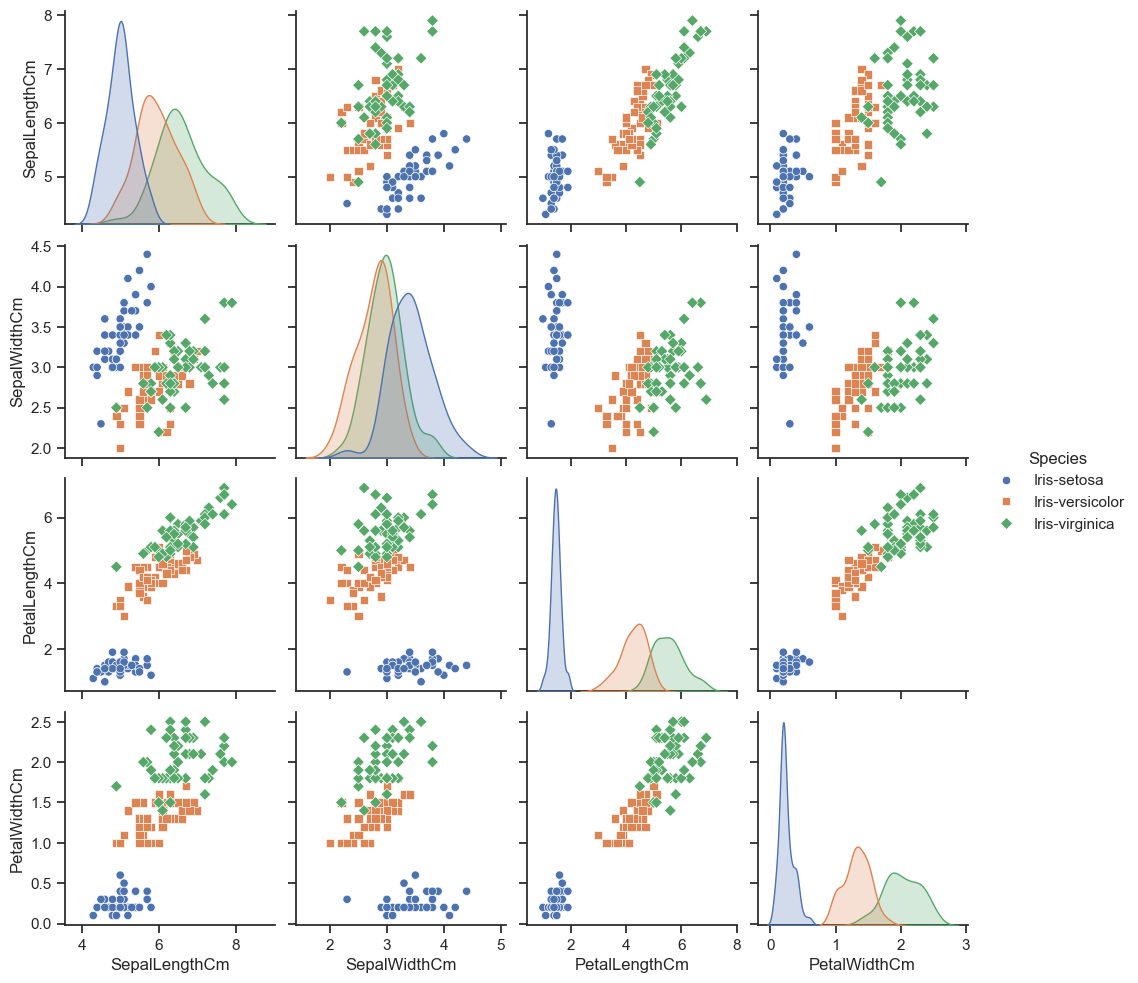

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt


# Use seaborn to create pair plots for all features
sns.set(style="ticks")
sns.pairplot(df, hue="Species", markers=["o", "s", "D"])




In [159]:
x = df.drop(columns = ['Species'])


# correlation matrix

<Axes: >

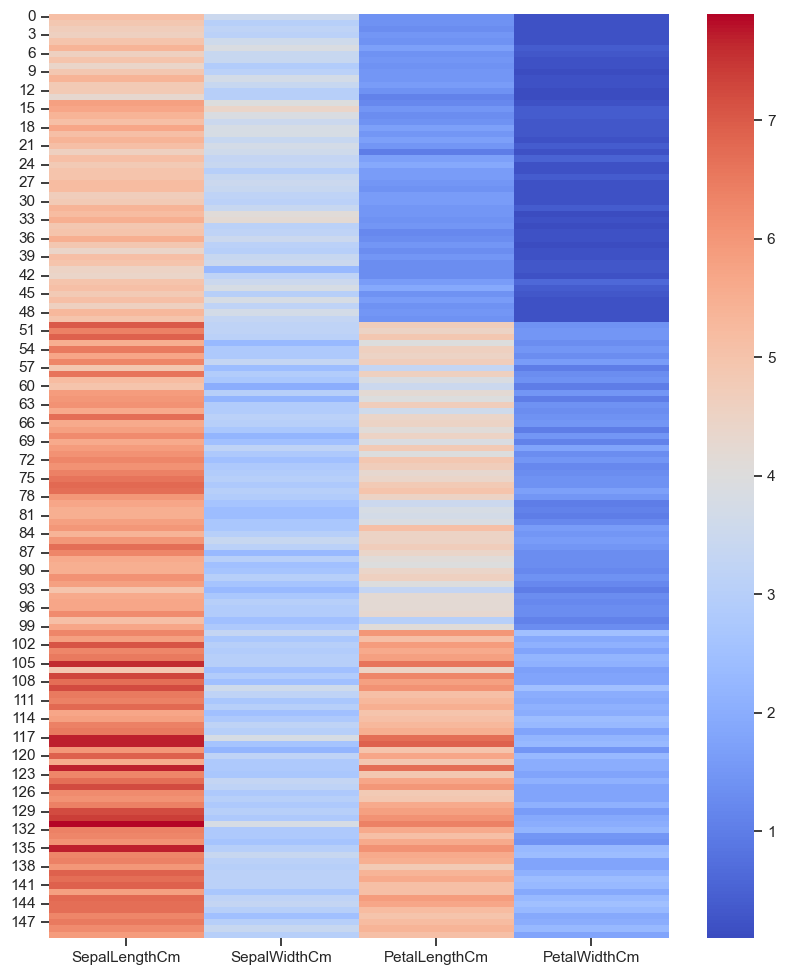

In [160]:
corr = x.corr()
fig,ax = plt.subplots(figsize =(10,12))
sns.heatmap(x, ax = ax, cmap = 'coolwarm')

# Label Encoder

In [161]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [162]:
df['Species'] = le.fit_transform(df['Species'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Model Traing

In [163]:
from sklearn.model_selection import train_test_split


In [164]:
x = df.drop(columns = ['Species'])

x.shape


(150, 4)

In [165]:
y = df['Species']

y.shape

(150,)

In [166]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [167]:
# use Logistic regression

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [168]:
# model training
model.fit(x_train,y_train)


LogisticRegression()

In [169]:

print("Accuracy:", model.score(x_test,y_test)*100)

Accuracy: 95.55555555555556


In [170]:
from sklearn.ensemble import RandomForestClassifier


In [171]:
# create an instance of the random forest classifier
clf = RandomForestClassifier(n_estimators=100)



In [172]:
# train the classifier on the training data
clf.fit(x_train, y_train)

# predict on the test set
pred = clf.predict(x_test)

# calculate accuracy
accuracy = accuracy_score(pred,y_test)
print(f"Accuracy: {accuracy}")  # Accuracy: 0.91


Accuracy: 0.9333333333333333


In [173]:
model.fit(x_train,y_train)

LogisticRegression()

In [174]:
print("Accuracy:", model.score(x_test,y_test)*100)

Accuracy: 95.55555555555556


In [175]:
# use DecisionTree Classifier

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [176]:
model.fit(x_train,y_train)


DecisionTreeClassifier()

In [177]:
print("Accuracy:", model.score(x_test,y_test)*100)

Accuracy: 93.33333333333333


In [178]:
#from sklearn.randomForestClassifier import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold

model = RandomForestClassifier(random_state=42)

# Define cross-validation method (5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
scores = cross_val_score(model, x, y, cv=kf)

print("Cross-validation scores:", scores)
print("Mean Accuracy:", np.mean(scores))

Cross-validation scores: [1.         0.96666667 0.93333333 0.93333333 0.96666667]
Mean Accuracy: 0.9600000000000002


In [179]:
model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [180]:
accuracy = model.score(x_test,y_test)*100
print(f"Accuracy: {accuracy}")  # Accuracy: 0.91

Accuracy: 93.33333333333333


In [181]:
accuracy=model.score(x_train,y_train)*100
print(f"Accuracy: {accuracy}")  

Accuracy: 100.0


In [182]:
import joblib

In [183]:
joblib.dump(model, "iris_rf_model.pkl")

print("Model trained and saved as iris_rf_model.pkl")

Model trained and saved as iris_rf_model.pkl
